# AIoT Project

In [39]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [2]:
time_start = time()

## Load configuration

In [2]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [36]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [3]:
client = pymongo.MongoClient(config["client"])

In [4]:
db = client[config["db"]]
coll = db[config["col"]]

In [5]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 50 keys in the collection


## Load data

In [6]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

Found 50 keys in the collection


In [7]:
print(results[0].keys())

dict_keys(['_id', 'data', 'gesture_id', 'user'])


In [7]:
def chop_edges_and_concat(results):
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(200).index, inplace=True)
            df.drop(df.head(200).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')


In [8]:
print(type(gestures))
print(len(gestures))
print(gestures['scroll-down-index']) 

<class 'dict'>
5
       acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z user
0      0.000 -0.503  0.842  3.171  2.744  1.463   01
1      0.001 -0.505  0.844  3.780  3.659  1.829   01
2     -0.004 -0.511  0.842  5.305  3.902  2.317   01
3     -0.003 -0.510  0.838  6.646  3.841  3.293   01
4      0.001 -0.510  0.833  7.439  3.841  4.634   01
...      ...    ...    ...    ...    ...    ...  ...
62999  0.234 -0.067  0.962 -0.793  3.841  2.683   02
63000  0.228 -0.061  0.964 -0.610  3.049  2.561   02
63001  0.231 -0.065  0.965 -0.549  2.561  2.073   02
63002  0.232 -0.072  0.976 -1.037  2.866  1.890   02
63003  0.231 -0.069  0.976 -1.341  2.866  2.134   02

[63004 rows x 7 columns]


## Explore the nature of the data

             Gesture  Duration (s)
0  scroll-down-index        630.04
1    scroll-up-index        659.81
2     texting-single        667.09
3  swipe-right-index        695.57
4   swipe-left-index        666.54


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


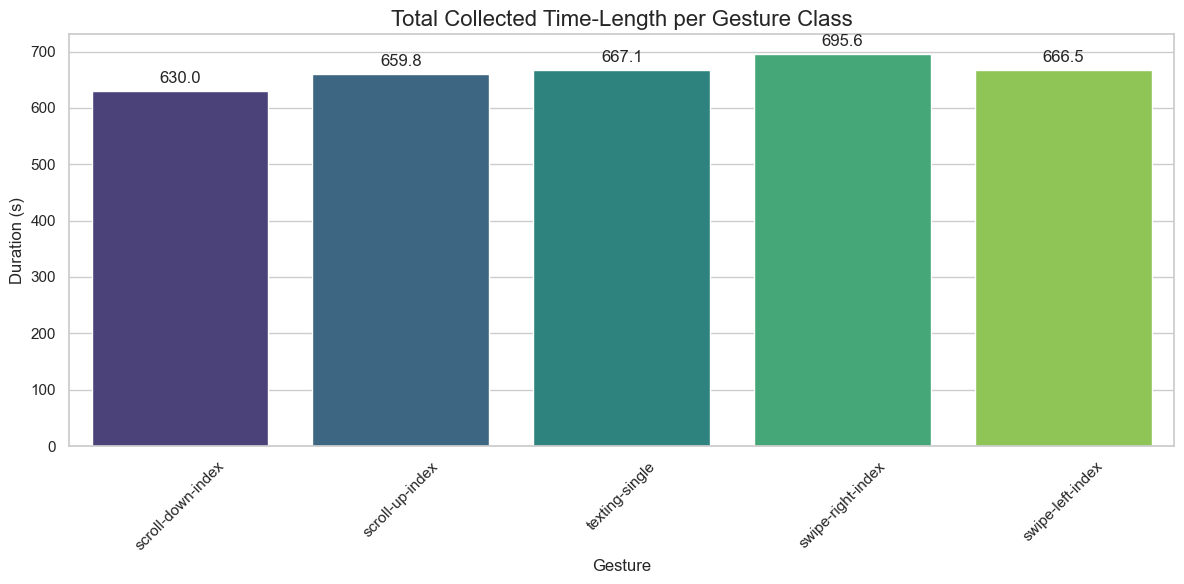

In [18]:
sampling_rate = 100
durations = []
for gesture_id, df in gestures.items():
    total_samples = len(df)
    duration_seconds = total_samples / sampling_rate
    durations.append({'Gesture': gesture_id, 'Duration (s)':
        duration_seconds})

duration_df = pd.DataFrame(durations)
print(duration_df)
   
plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

In [24]:
def clean_nans(gestures):   
    for gesture_name, df in gestures.items():
        print(f"\nGesture: {gesture_name}")
        
        # Calculate total missing values for this specific gesture DataFrame
        total_missing = df.isnull().sum().sum()
        
        if total_missing == 0:
            print("Status: 0 missing values.")
        else:
            print("Status: Missing values found!")
            # This prints the breakdown of NaNs for every sensor column (acc_x, acc_y, etc.)
            print(df.isnull().sum())
            # Limit the interpolation to a small number of consecutive missing values (e.g., 3 samples)
            df.interpolate(method='linear', limit=3, limit_direction='both', inplace=True)    
            
# clean_nans(gestures)

## Data Processing

In [ ]:
# df = dfs[0]
# print('FOCUSING ON ', df[0])
# data = df[1]
# plot_instance_time_domain(data)
# # plot_instance_3d(data, axiss_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(data, axes_list=['acc_x', 'acc_y', 'acc_z'])
# plot_heatmap(data)

# # slice data into windows
# clips = sliding_window_pd(data, ws=2000, overlap=1000, print_stats=False)
# total_clips = len(clips)
# print(f'Total clips: {total_clips}')
# fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
# plot_instance_time_domain(fclips[1])
# # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])


We Filter for Glitches/Outliers

In [35]:


def clean_sensor_outliers(df, window_size=50, threshold=3.0):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    # Define your 6 sensor columns from the MetaMotionR IMU
    sensor_columns = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    
    for col in sensor_columns:
        # 1. Calculate Rolling Mean and Standard Deviation
        # 'center=True' ensures the window looks at points both before and after the current row
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        # 2. Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        
        # 3. Find how many outliers we are catching (Great for your EDA Report!)
        outlier_count = (rolling_z_scores > threshold).sum()
        print(f"Cleaned {outlier_count} glitches in {col}")
        
        # 4. Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        
        # 5. Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=100, threshold=3.0)

# Check the first few rows to ensure everything looks correct
display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


Cleaning gesture: scroll-down-index
Cleaned 591 glitches in acc_x
Cleaned 139 glitches in acc_y
Cleaned 387 glitches in acc_z
Cleaned 136 glitches in gyr_x
Cleaned 660 glitches in gyr_y
Cleaned 86 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 329 glitches in acc_x
Cleaned 57 glitches in acc_y
Cleaned 273 glitches in acc_z
Cleaned 61 glitches in gyr_x
Cleaned 622 glitches in gyr_y
Cleaned 57 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 553 glitches in acc_x
Cleaned 331 glitches in acc_y
Cleaned 184 glitches in acc_z
Cleaned 87 glitches in gyr_x
Cleaned 258 glitches in gyr_y
Cleaned 144 glitches in gyr_z
Cleaning gesture: swipe-right-index
Cleaned 420 glitches in acc_x
Cleaned 151 glitches in acc_y
Cleaned 498 glitches in acc_z
Cleaned 241 glitches in gyr_x
Cleaned 503 glitches in gyr_y
Cleaned 86 glitches in gyr_z
Cleaning gesture: swipe-left-index
Cleaned 318 glitches in acc_x
Cleaned 37 glitches in acc_y
Cleaned 499 glitches in acc_z
Cleaned 24 glitches in 

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,user
0,-0.086,-0.269,0.960,0.122,2.317,-0.671,01
1,-0.093,-0.268,0.964,0.671,4.085,-1.768,01
2,-0.097,-0.268,0.962,1.707,6.585,-3.232,01
3,-0.089,-0.266,0.962,2.683,9.939,-5.122,01
4,-0.095,-0.268,0.958,3.963,12.866,-7.378,01


In [21]:
# strucure of cleaned_gestures:
print(type(cleaned_gestures))
print(cleaned_gestures.keys())
print(len(cleaned_gestures))
print(len(cleaned_gestures['scroll-down-index']))
print(cleaned_gestures['scroll-down-index'])

<class 'dict'>
dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index'])
5
63004
       acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z user
0      0.000 -0.503  0.842  3.171  2.744  1.463   01
1      0.001 -0.505  0.844  3.780  3.659  1.829   01
2     -0.004 -0.511  0.842  5.305  3.902  2.317   01
3     -0.003 -0.510  0.838  6.646  3.841  3.293   01
4      0.001 -0.510  0.833  7.439  3.841  4.634   01
...      ...    ...    ...    ...    ...    ...  ...
62999  0.234 -0.067  0.962 -0.793  3.841  2.683   02
63000  0.228 -0.061  0.964 -0.610  3.049  2.561   02
63001  0.231 -0.065  0.965 -0.549  2.561  2.073   02
63002  0.232 -0.072  0.976 -1.037  2.866  1.890   02
63003  0.231 -0.069  0.976 -1.341  2.866  2.134   02

[63004 rows x 7 columns]


['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index']
GESTURE scroll-down-index VAGGOS VS ELMOS


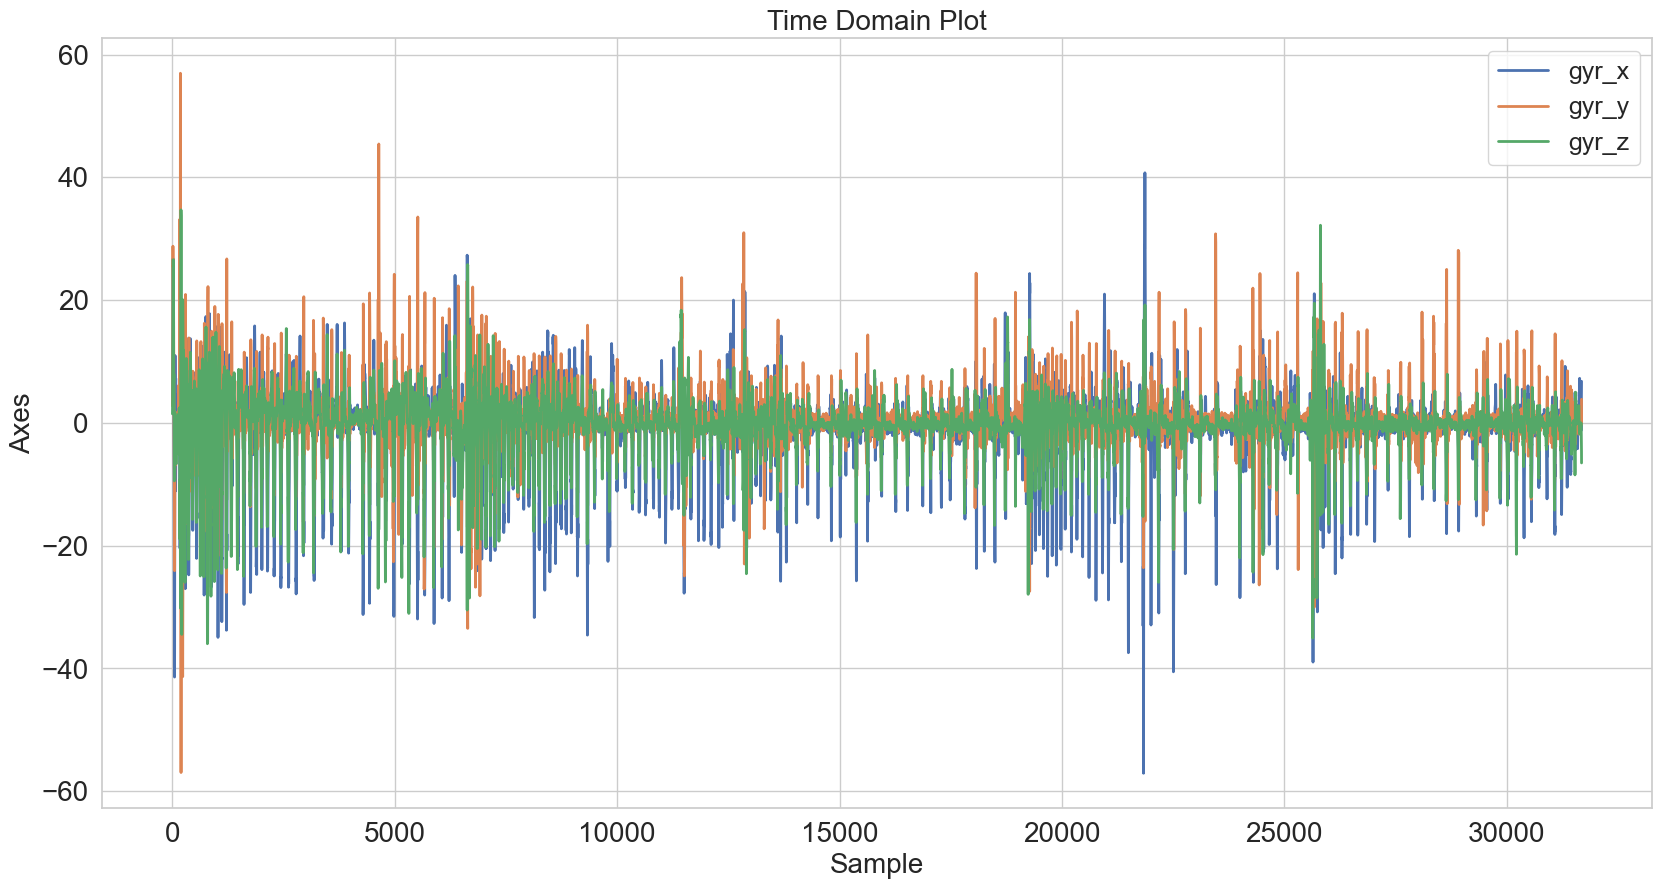

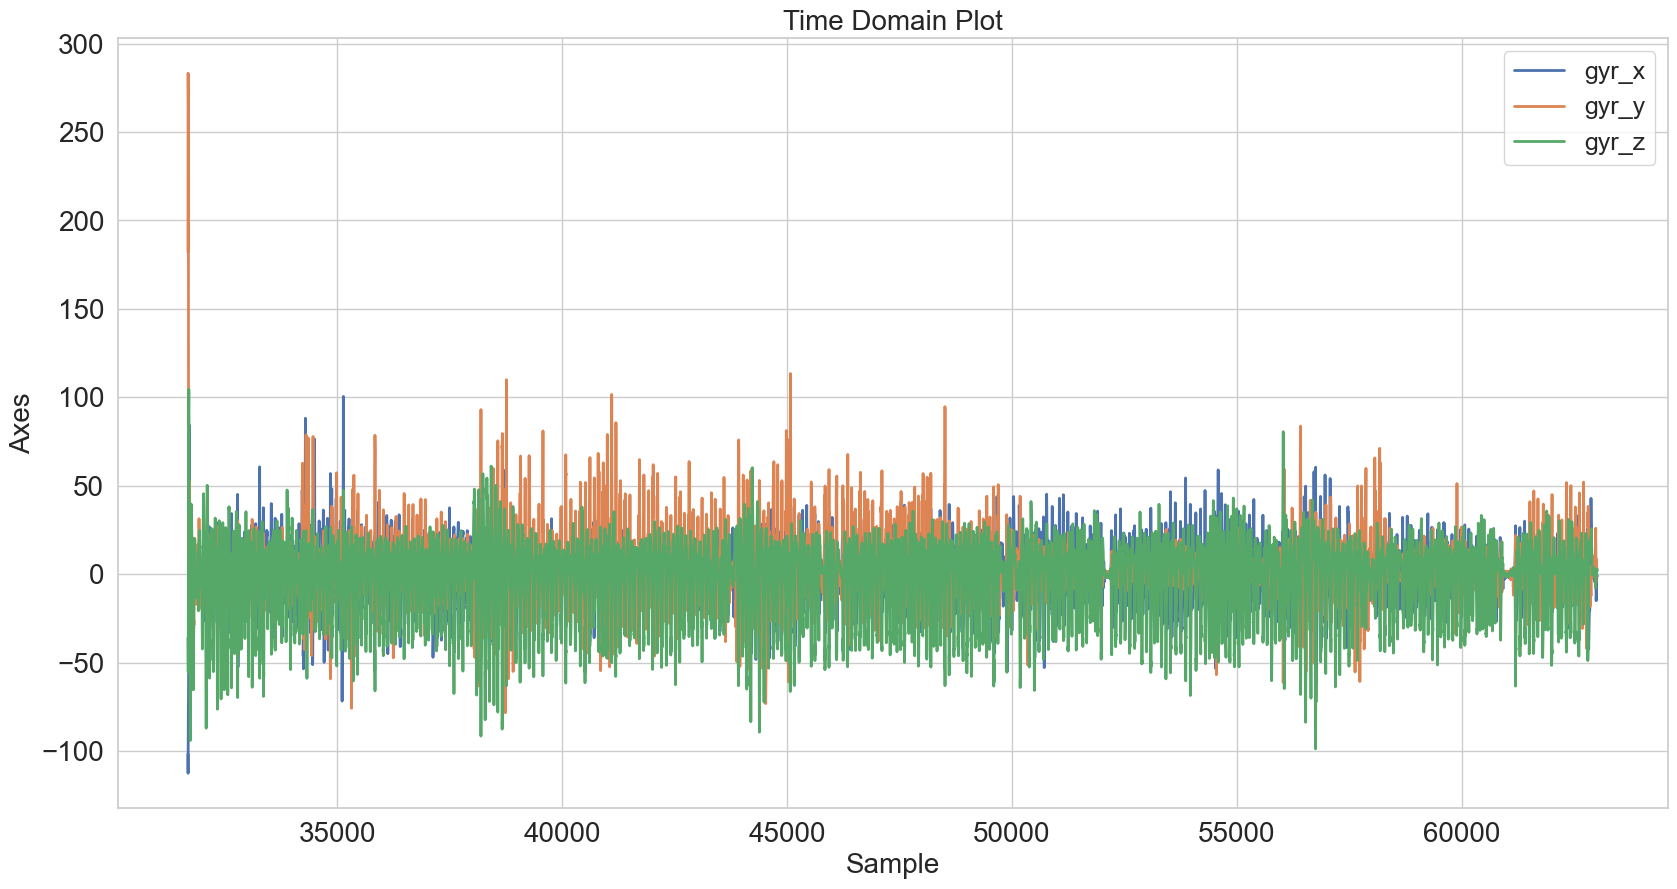

GESTURE scroll-up-index VAGGOS VS ELMOS


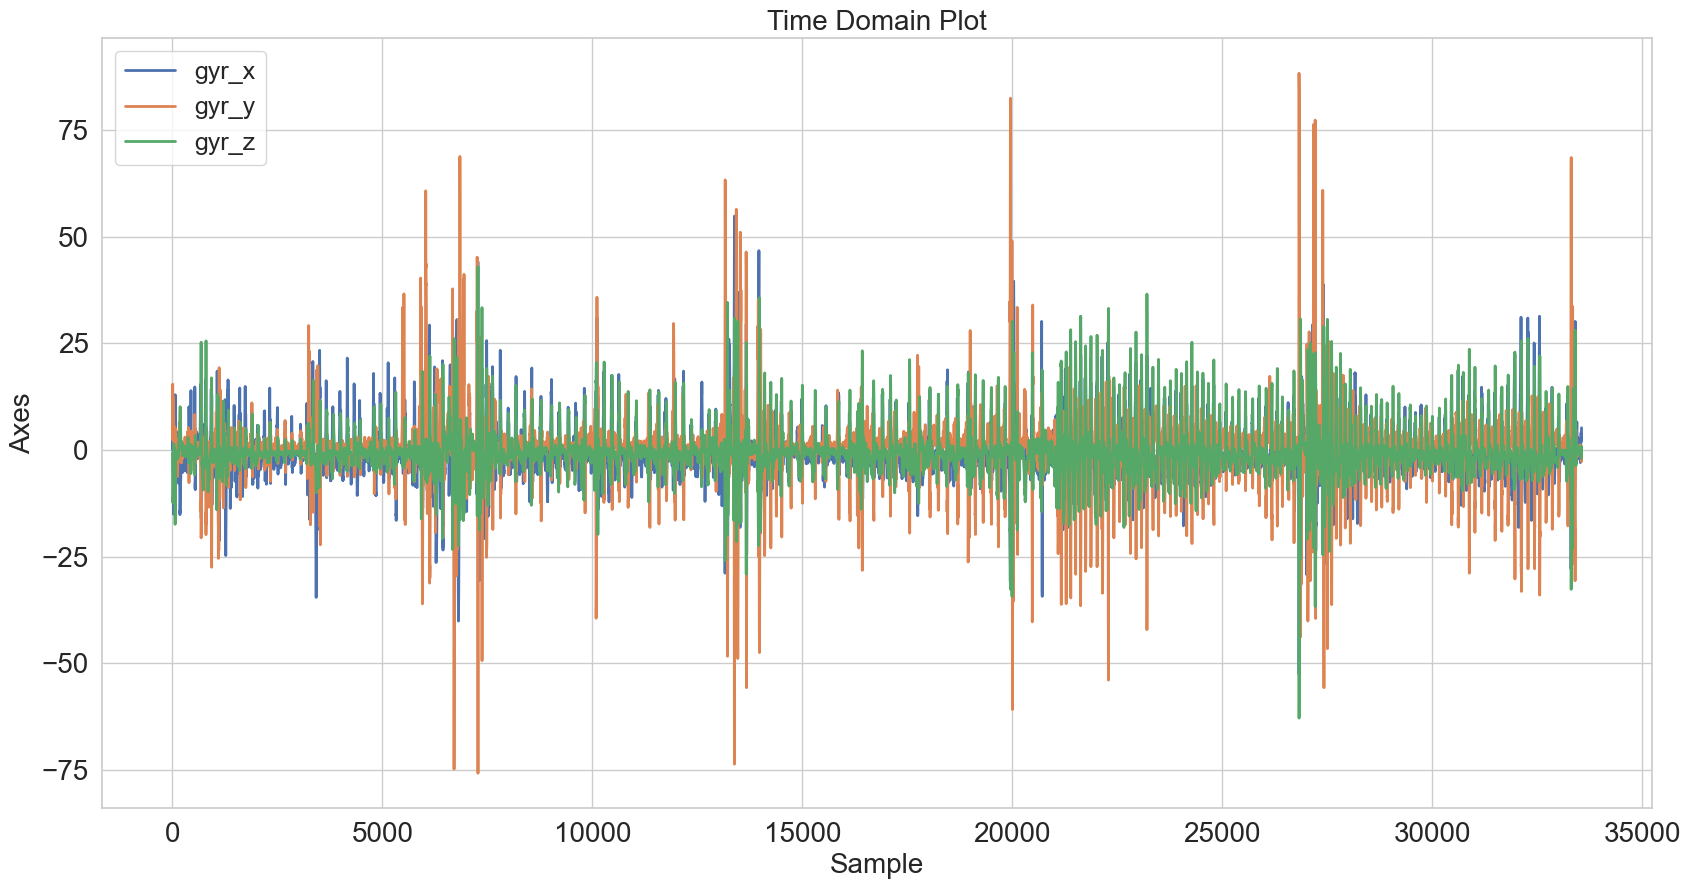

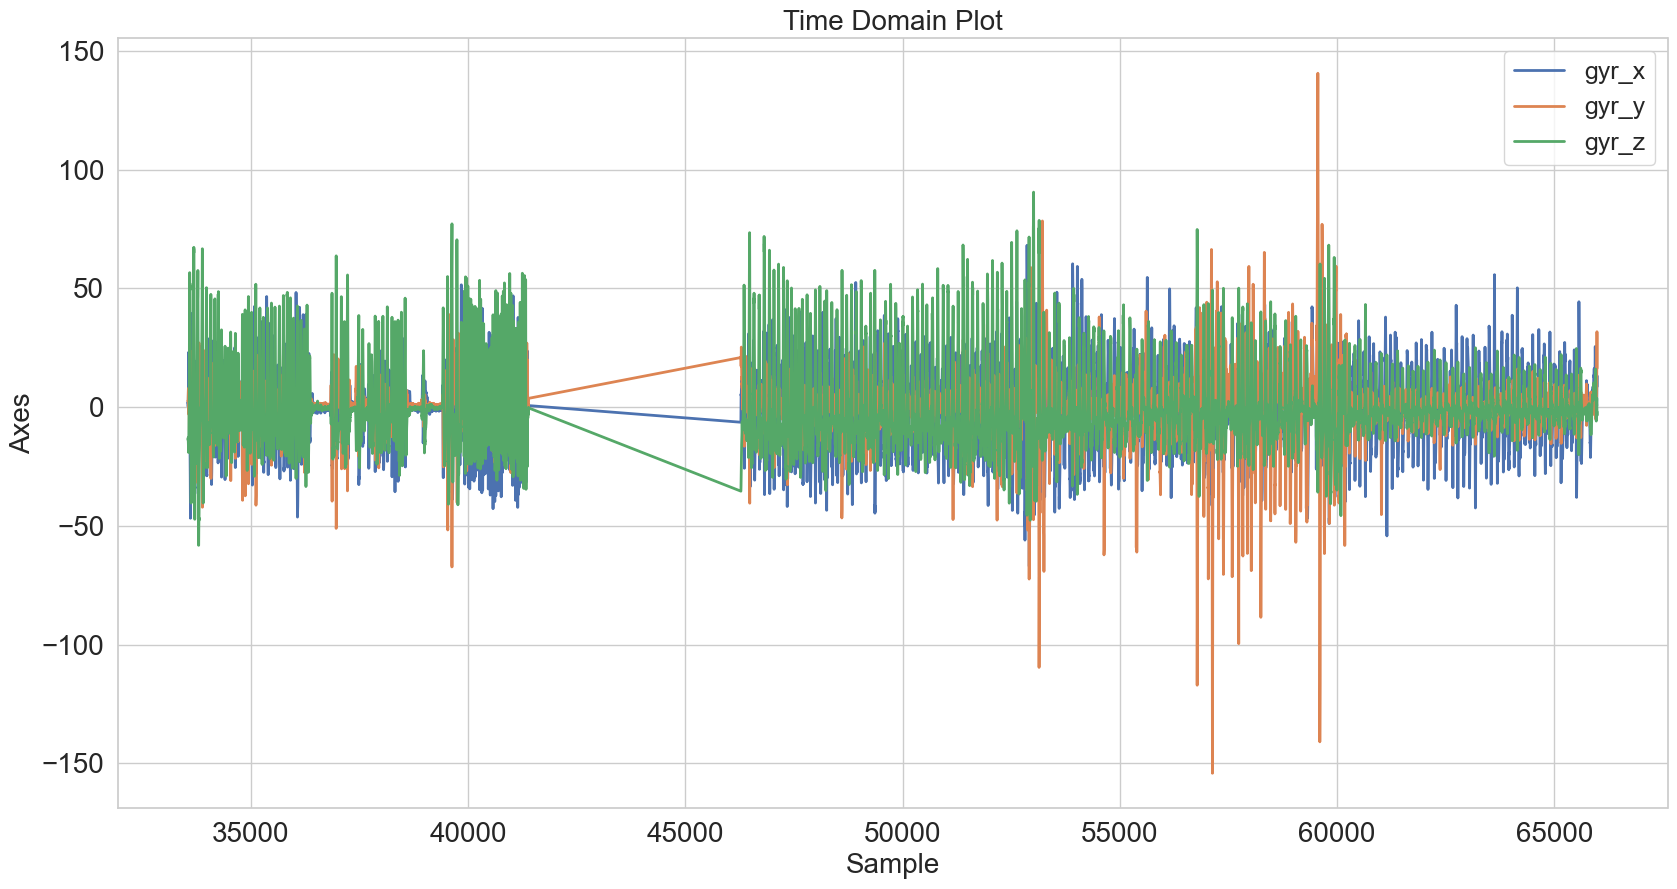

GESTURE texting-single VAGGOS VS ELMOS


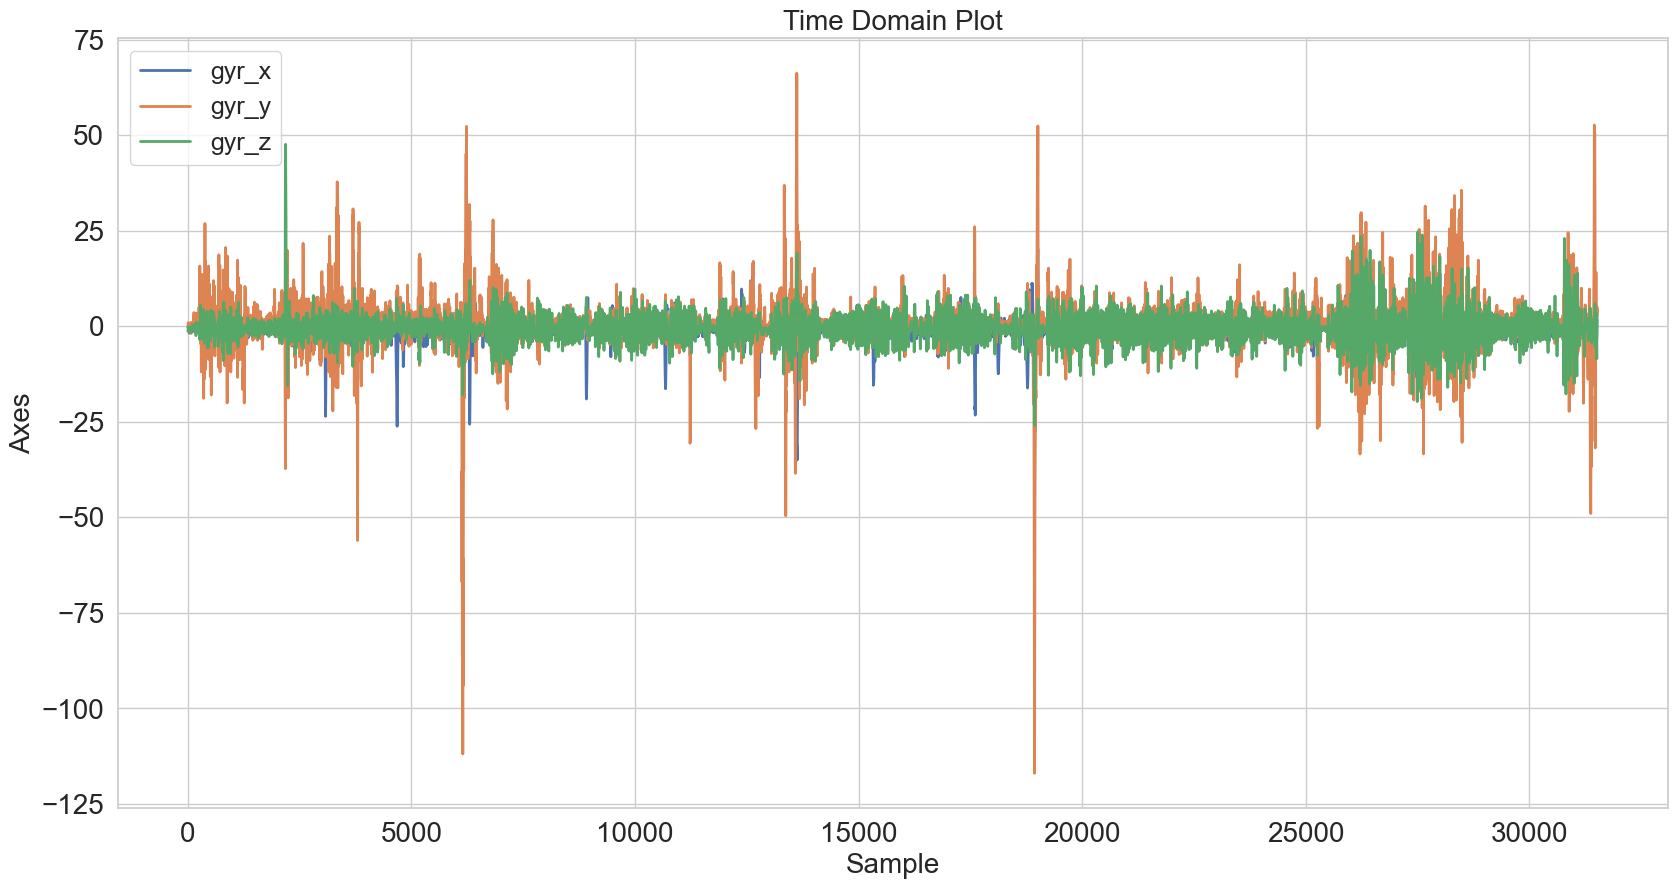

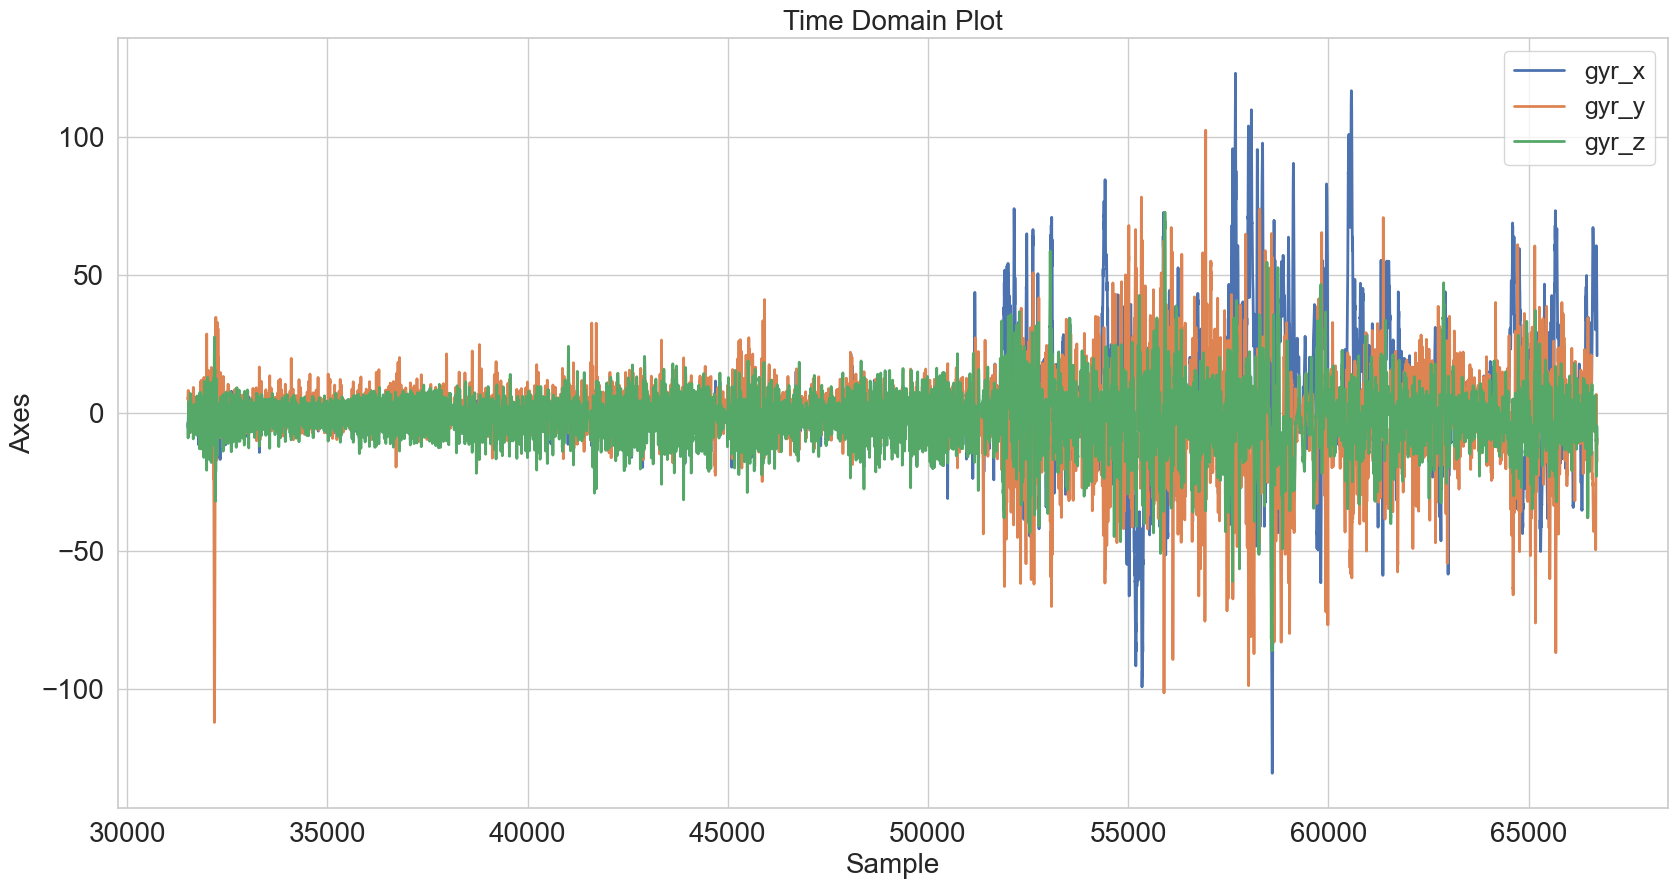

GESTURE swipe-right-index VAGGOS VS ELMOS


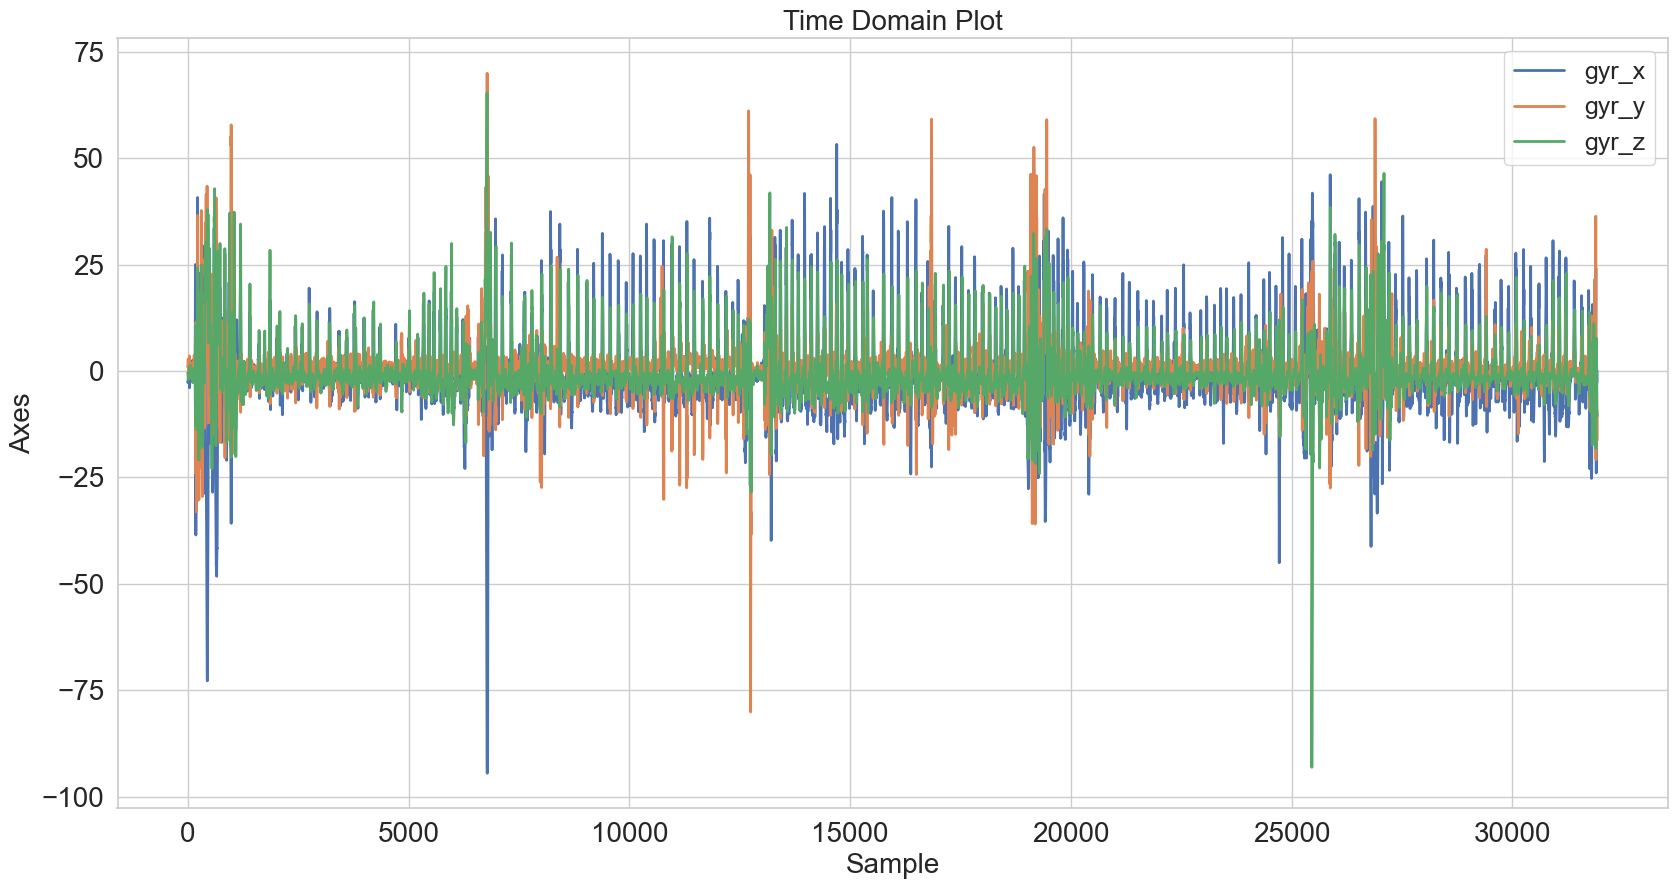

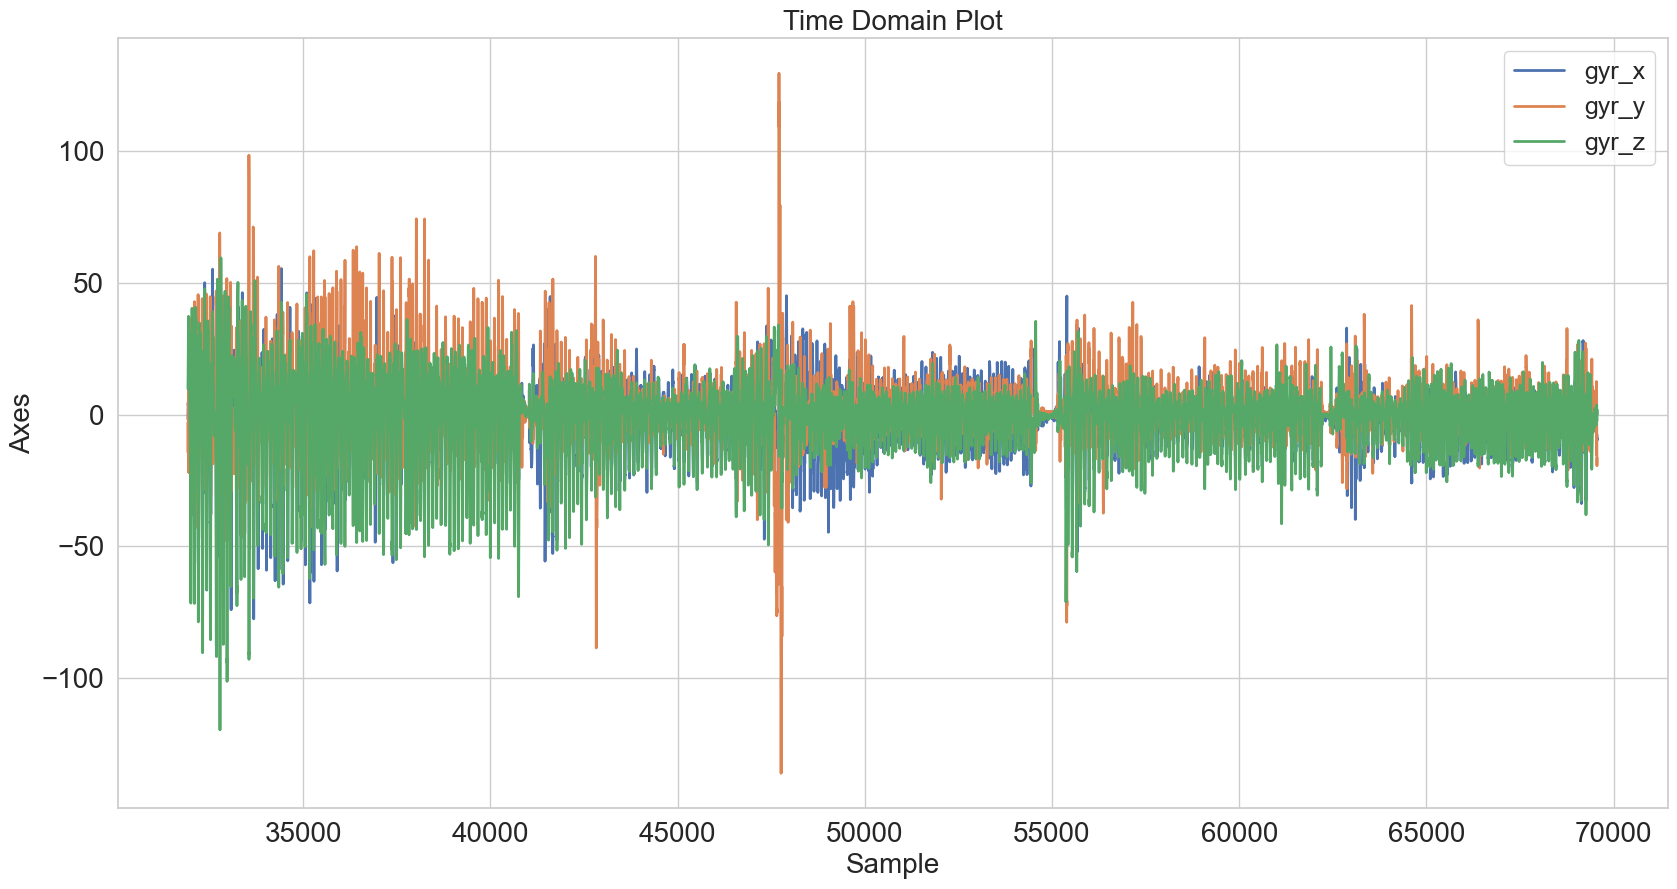

GESTURE swipe-left-index VAGGOS VS ELMOS


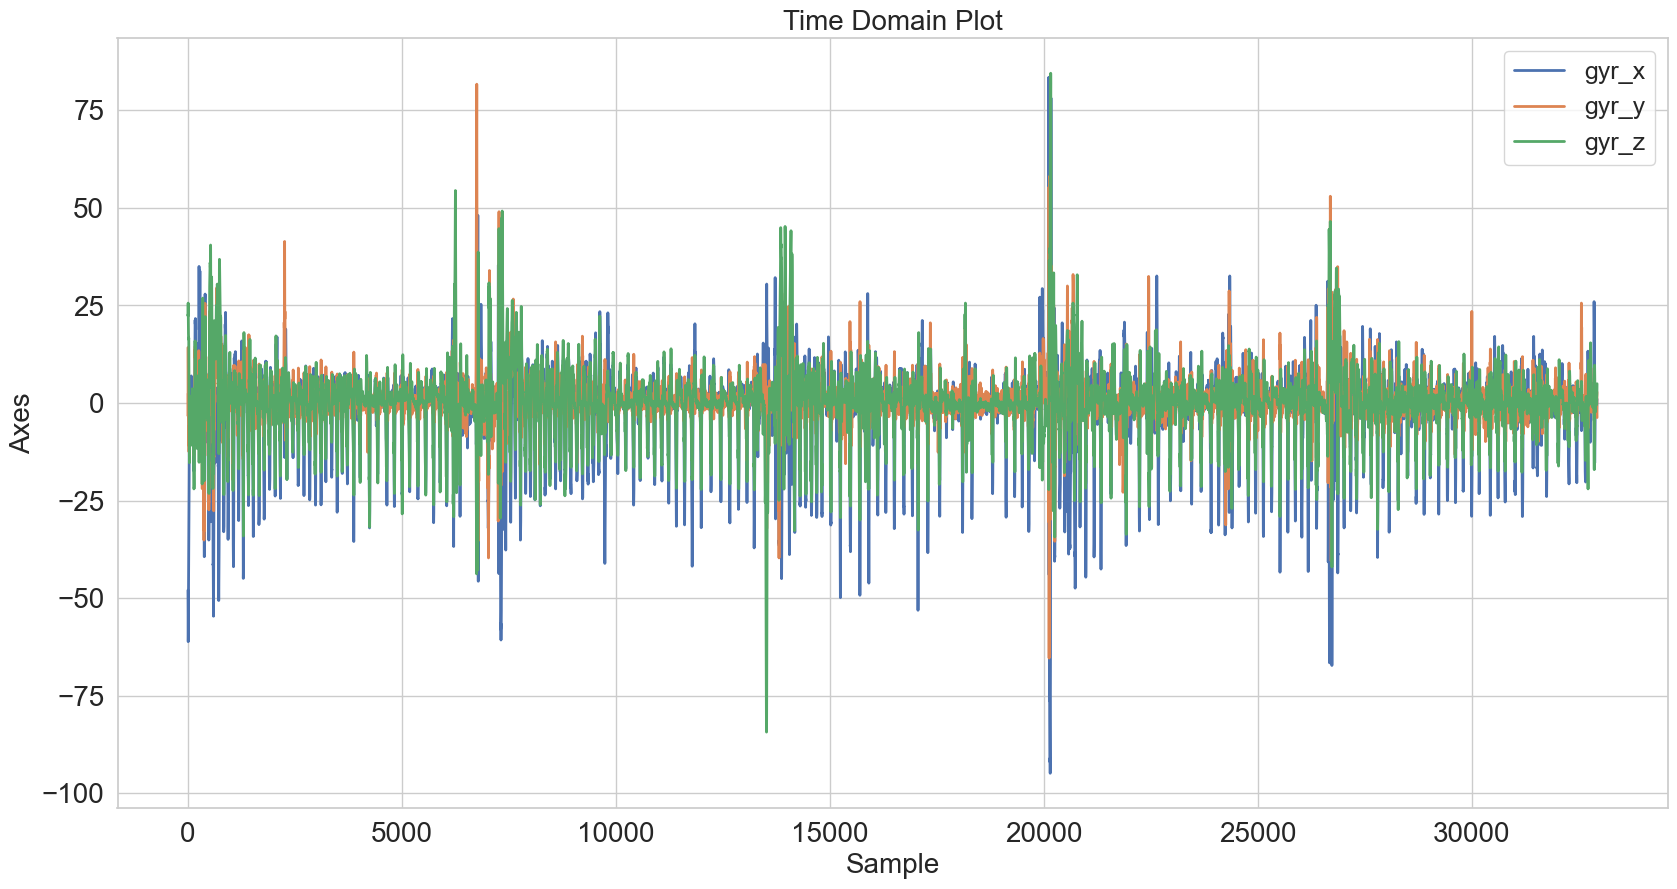

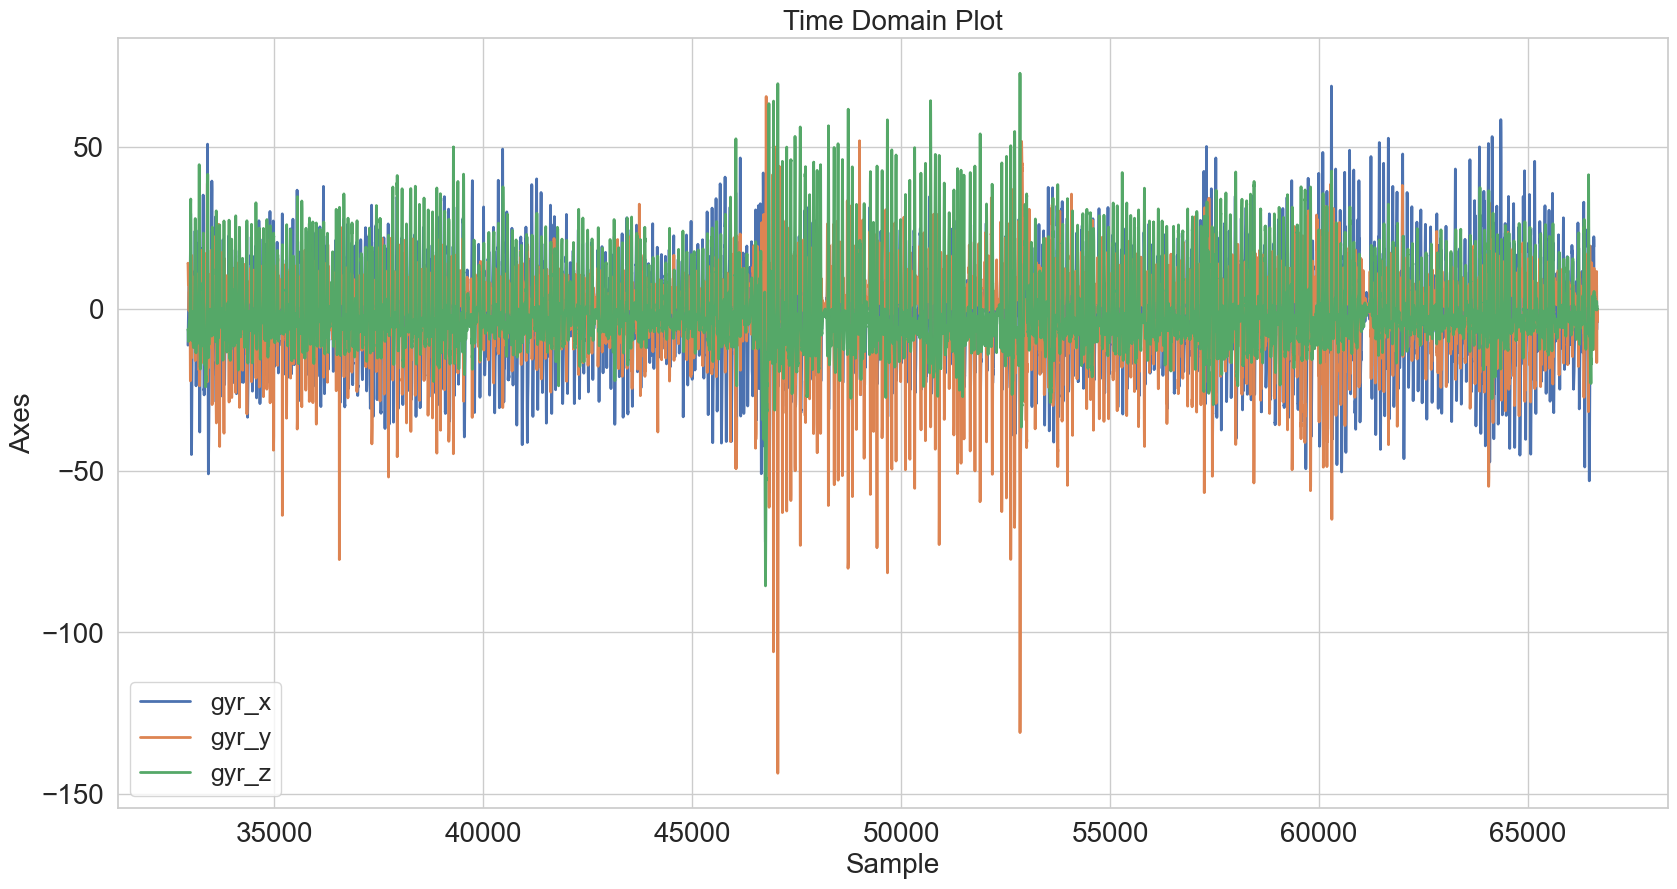

In [43]:
keys = list(gestures.keys())
print(keys)
users = gestures['scroll-up-index']['user'].unique()


for key in keys:
    print(f'GESTURE {key} VAGGOS VS ELMOS')
    vaggos = cleaned_gestures[key][cleaned_gestures[key]['user'] == users[0]]
    elmos = cleaned_gestures[key][cleaned_gestures[key]['user'] == users[1]]

    plot_instance_time_domain(vaggos.drop(columns='user'), axes=['gyr_x', 'gyr_y', 'gyr_z'])
    plot_instance_time_domain(elmos.drop(columns='user'), axes=['gyr_x', 'gyr_y', 'gyr_z'])
    
    
    # for axis in axes:
    #     print(f'AXIS: {axis}')
    #     plot_distribution_analysis(vaggos, column_name=axis)
    #     plot_distribution_analysis(elmos, column_name=axis)
        


## Sensor-type grouped scaling

In [11]:

def scale_gestures(gestures_train, gestures_val):
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(gestures_train, gestures_val)
    

## We use sliding widnowing to create our samples

In [12]:
def window_and_filter_gestures(cleaned_gestures):
    clips_arr = []
    clipped_gestures = {}
    for id, data in cleaned_gestures.items():
        # slice data into windows
        clips = sliding_window_pd(data.drop(columns='user'), ws=2000, overlap=1000, print_stats=False)
        total_clips = len(clips)
        # print(f'Total clips: {total_clips}')
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
        clipped_gestures[id] = fclips
        print(f'GESTURE_ID: {id}')
        # plot_instance_time_domain(fclips[1], id)
        # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
        # plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])
    return (clipped_gestures, clips_arr)

# clipped_train, train_distr = window_and_filter_gestures(gestures_train)
# clipped_val, val_distr = window_and_filter_gestures(gestures_val)
# print("clipped_train keys: ", clipped_train.keys(), "\nlength: ", len(clipped_train))
# print("clipped_val keys: ", clipped_val.keys(), "\nlength: ", len(clipped_val))
# print(len(clipped_train['scroll-up-index']), "clips in clipped_train for scroll-up-index")


In [44]:
# 2. Convert to a DataFrame for easier plotting
# train_distr_df = pd.DataFrame(train_distr)
# val_distr_df = pd.DataFrame(val_distr)

# print(train_distr_df)
# plot_bar(train_distr_df, title='Training Total Clips per Gesture Class')

# print(val_distr_df)
# plot_bar(val_distr_df, title='Validation Total Clips per Gesture Class')

## We flatten each sample 

In [13]:
# print(clipped_gestures.keys())
# print(clipped_train['scroll-down-index'][0])

def flatten_gestures(gesture_clips):
    flattened_clips = {}
    for id, clips in gesture_clips.items():
        flattened_clips[id] = flatten_instances_df(clips)
    return flattened_clips

# train_clips_flattened = flatten_gestures(clipped_train)
# val_clips_flattened = flatten_gestures(clipped_val)

# print(len(train_clips_flattened['scroll-up-index']), "flattened clips in train_clips_flattened for scroll-up-index")    
# print(len(val_clips_flattened['scroll-up-index']), "flattened clips in val_clips_flattened for scroll-up-index")    
# print(train_clips_flattened['scroll-up-index'])

## Classifier - Statistical Learning

### unpack dict data for scikitlearn model

In [14]:
def prepare_xy(flattened_dict):
    X = pd.concat(flattened_dict.values(), ignore_index=True).to_numpy()
    
    y = []
    for gesture_name, df in flattened_dict.items():
        y.extend([gesture_name] * len(df))
        
    return X, np.array(y)

# X_train, y_train = prepare_xy(train_clips_flattened)
# X_val, y_val = prepare_xy(val_clips_flattened)

# print("X_train shape: ", X_train.shape)
# print("Y_train shape: ", y_train.shape)

## Leave One Subject Out Cross Validation LOSO-CV

In [15]:
def process_fold(gestures_train, gestures_val):
    # scaling
    scale_gestures(gestures_train, gestures_val)
    
    # windoing and filtering
    clipped_train, train_distr = window_and_filter_gestures(gestures_train)
    clipped_val, val_distr = window_and_filter_gestures(gestures_val)
    
    # print distr if we want/copy and paste from appropriate cell
    
    # flattening 
    train_clips_flattened = flatten_gestures(clipped_train)
    val_clips_flattened = flatten_gestures(clipped_val)
    
    # break open the dict format to feed to model
    X_train, y_train = prepare_xy(train_clips_flattened)
    X_val, y_val = prepare_xy(val_clips_flattened)
    
    # classification, RN mono me ena classifier gia testing
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    y_preds = rf_model.predict(X_val)
    
    return y_val, y_preds, 

In [22]:
unique_users = ['01', '02']
classification_results = {}

# default cleaning
gestures = chop_edges_and_concat(results)
# clean_nans(gestures)
purge_outliers_all_gestures(gestures)

for holdout_user in unique_users:
    print(f"--- Running Fold: User {holdout_user} is Validation ---")
    
    fold_train = {gid: df[df['user'] != holdout_user].copy() for gid, df in gestures.items()}
    fold_val = {gid: df[df['user'] == holdout_user].copy() for gid, df in gestures.items()}
    
    y_true, y_pred = process_fold(fold_train, fold_val)
    
    classification_results[holdout_user] = {'true': y_true, 'pred': y_pred}
    
        

# print("gestures_train keys: ", gestures_train.keys(), "\nlength: ", len(gestures_train))
# print("gestures_val keys: ", gestures_val.keys(), "\nlength: ", len(gestures_val))
# print("Example X_train shape: ", gestures_train['scroll-up-index'])

Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 165 glitches in acc_x
Cleaned 39 glitches in acc_y
Cleaned 65 glitches in acc_z
Cleaned 4 glitches in gyr_x
Cleaned 39 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 117 glitches in acc_x
Cleaned 27 glitches in acc_y
Cleaned 33 glitches in acc_z
Cleaned 6 glitches in gyr_x
Cleaned 62 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 514 glitches in acc_x
Cleaned 303 glitches in acc_y
Cleaned 125 glitches in acc_z
Cleaned 32 glitches in gyr_x
Cleaned 78 glitches in gyr_y
Cleaned 31 glitches in gyr_z
Cleaning gesture: swipe-right-index
Cleaned 121 glitches in acc_x
Cleaned 53 glitche

## K FOLD RESULTS

FINAL LOSO-CV RESULTS:
                   precision    recall  f1-score   support

scroll-down-index       0.00      0.00      0.00        60
  scroll-up-index       0.19      0.39      0.26        56
 swipe-left-index       0.28      0.43      0.34        63
swipe-right-index       0.56      0.27      0.37        66
   texting-single       1.00      1.00      1.00        64

         accuracy                           0.42       309
        macro avg       0.41      0.42      0.39       309
     weighted avg       0.42      0.42      0.40       309



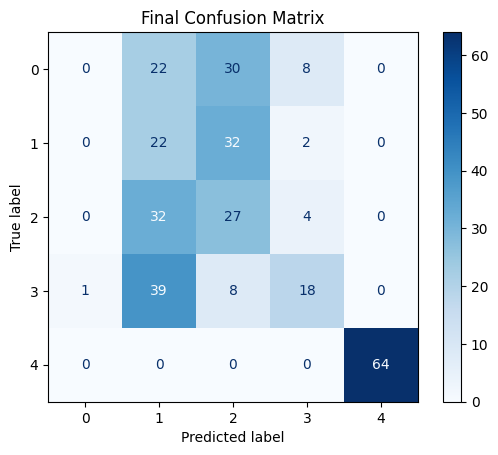

In [23]:
# we combina all fold results
final_true = np.concatenate([res['true'] for res in classification_results.values()])
final_pred = np.concatenate([res['pred'] for res in classification_results.values()])

print("FINAL LOSO-CV RESULTS:")
print(classification_report(final_true, final_pred))
conf_matrix = confusion_matrix(final_true, final_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

### Evaluate classifiers

SVM Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      0.97      0.98        30
  scroll-up-index       1.00      0.77      0.87        31
 swipe-left-index       1.00      1.00      1.00        32
swipe-right-index       0.82      1.00      0.90        36
   texting-single       1.00      1.00      1.00        34

         accuracy                           0.95       163
        macro avg       0.96      0.95      0.95       163
     weighted avg       0.96      0.95      0.95       163



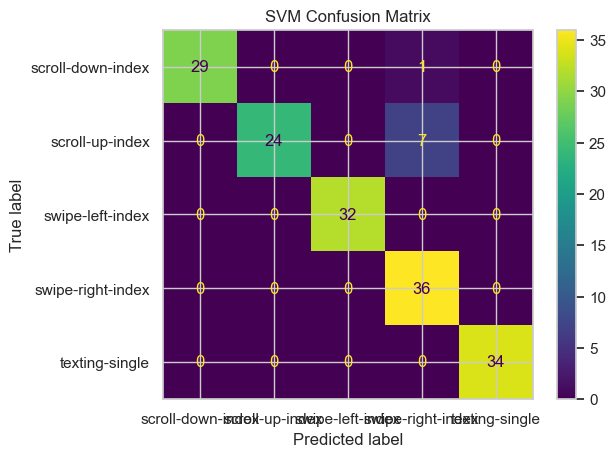

In [63]:
svm_model = SVC(kernel='rbf', gamma='auto')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

print("SVM Classification Report:\n", classification_report(y_val, y_pred_svm))
confusion_matrix_svm = confusion_matrix(y_val, y_pred_svm, labels=svm_model.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_svm, display_labels=svm_model.classes_)
disp_svm.plot()
plt.title("SVM Confusion Matrix")
plt.show()

Random Forest Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00        30
  scroll-up-index       1.00      1.00      1.00        31
 swipe-left-index       1.00      1.00      1.00        32
swipe-right-index       1.00      1.00      1.00        36
   texting-single       1.00      1.00      1.00        34

         accuracy                           1.00       163
        macro avg       1.00      1.00      1.00       163
     weighted avg       1.00      1.00      1.00       163



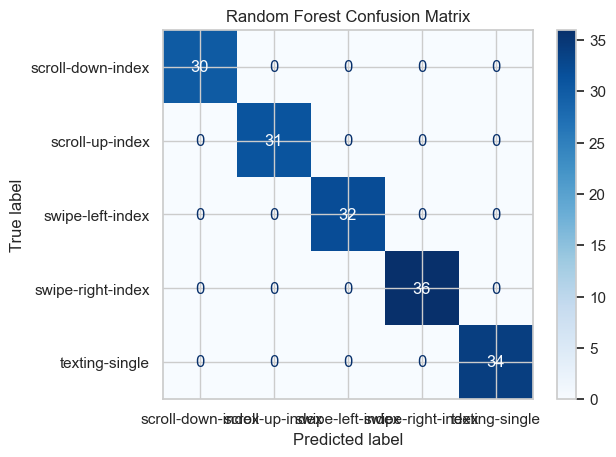

In [64]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

print("Random Forest Classification Report:\n", classification_report(y_val, rf_pred))
confusion_matrix_rf = confusion_matrix(y_val, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

Logistic Regression Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00        30
  scroll-up-index       1.00      1.00      1.00        31
 swipe-left-index       1.00      1.00      1.00        32
swipe-right-index       1.00      1.00      1.00        36
   texting-single       1.00      1.00      1.00        34

         accuracy                           1.00       163
        macro avg       1.00      1.00      1.00       163
     weighted avg       1.00      1.00      1.00       163



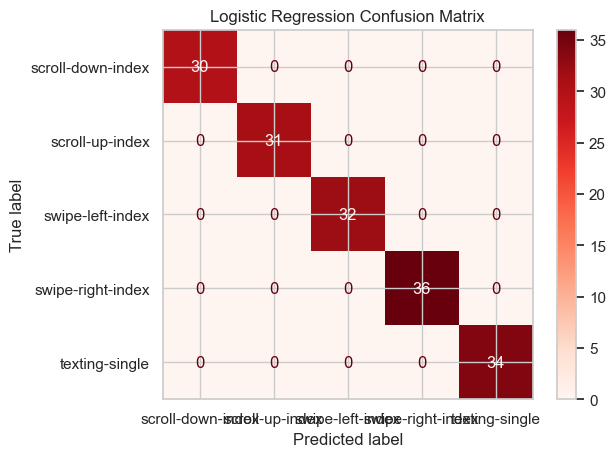

In [65]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_val)

print("Logistic Regression Classification Report:\n", classification_report(y_val, log_pred))
confusion_matrix_log = confusion_matrix(y_val, log_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log, display_labels=log_model.classes_)
disp_log.plot(cmap=plt.cm.Reds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from torch import nn

cnn_model = 
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_val)

print("Logistic Regression Classification Report:\n", classification_report(y_val, log_pred))
confusion_matrix_log = confusion_matrix(y_val, log_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log, display_labels=log_model.classes_)
disp_log.plot(cmap=plt.cm.Reds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier